# Channel Flow - RANS (mixing length)

### Import Library

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Domain Setup

In [2]:
LH = 1.0   # Full channel height
LW = 2.0   # Streamwise domain length (periodic in x)

Dh = 2 * LH  # Hydraulic diameter for wide channel: Dh = 4A/P = 4(H*W)/(2W) = 2H
print("Hydraulic diameter (Dh):", Dh)

Re = 6000                  # Reynolds number (based on Dh and bulk velocity)
Nu = 1.5e-5                # Kinematic viscosity [m^2/s]
U_bulk = Re * Nu / Dh      # Bulk inlet velocity from Re definition
print("Bulk velocity (U_bulk):", U_bulk)

rho = 1.2                  # Air density [kg/m^3]

Hydraulic diameter (Dh): 2.0
Bulk velocity (U_bulk): 0.045


### Compute y+

In [3]:
target_y_plus = 1.0

# Blasius correlation for INTERNAL flow (channel/pipe): valid for Re < 10^5
# Darcy friction factor: f = 0.316 / Re^0.25
# Skin friction coeff:   Cf = f / 4 = 0.079 / Re^0.25
C_f = 0.079 / Re**0.25
print("Friction coefficient (Cf):", C_f)

tau_w = C_f * 0.5 * rho * U_bulk**2
print("Wall shear stress (tau_w):", tau_w)

u_tau = np.sqrt(tau_w / rho)
print("Friction velocity (u_tau):", u_tau)

# First cell height to achieve target y+
y1 = target_y_plus * Nu / u_tau
print("First cell height (y1):", y1)

# Friction Reynolds number Re_tau = u_tau * (LH/2) / Nu
H = LH / 2   # Half-channel height (use symmetry)
Re_tau = u_tau * H / Nu
print("Friction Reynolds number (Re_tau):", Re_tau)

Friction coefficient (Cf): 0.008976132995093245
Wall shear stress (tau_w): 1.0906001589038292e-05
Friction velocity (u_tau): 0.003014686494070637
First cell height (y1): 0.0049756417556194935
Friction Reynolds number (Re_tau): 100.48954980235457


### Compute the Normal Grid

Grid points: 21
First cell height: 0.004976  (target y1=0.004976)
Last point: 0.5000  (should be H=0.5)
y+ at first point: 1.000  (target: 1.0)


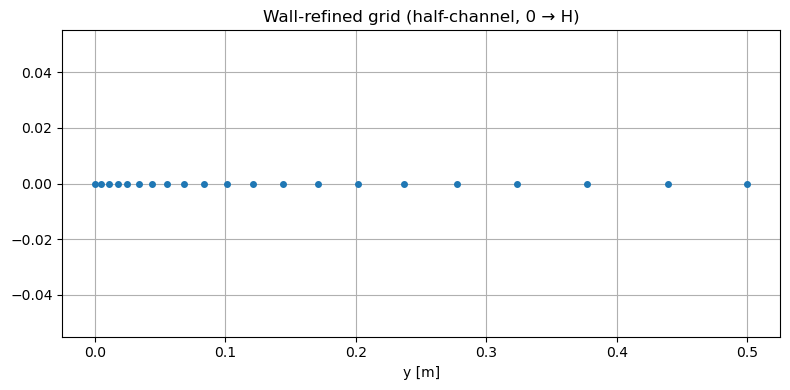

In [4]:
def exponential_grid_stretching(y1, r, H, N_max=200):
    """
    Build a wall-refined 1D grid from y=0 to y=H.
    y1   : first cell height (controls y+ at wall)
    r    : stretching ratio between successive cells
    H    : domain extent (half-channel height)
    Returns y array that always ends exactly at H.
    """
    y = [0.0]
    dy = y1
    while y[-1] + dy < H:
        y.append(y[-1] + dy)
        dy *= r
        if len(y) > N_max:
            break
    y.append(H)   # force last point exactly at centerline
    return np.array(y)


r = 1.15
y_half = exponential_grid_stretching(y1, r, H)
N = len(y_half)
print(f"Grid points: {N}")
print(f"First cell height: {y_half[1]:.6f}  (target y1={y1:.6f})")
print(f"Last point: {y_half[-1]:.4f}  (should be H={H})")
print(f"y+ at first point: {y_half[1] * u_tau / Nu:.3f}  (target: {target_y_plus})")

plt.figure(figsize=(8, 4))
plt.plot(y_half, np.zeros_like(y_half), 'o', markersize=4)
plt.xlabel("y [m]")
plt.title("Wall-refined grid (half-channel, 0 → H)")
plt.grid(True)
plt.tight_layout()
plt.show()

### Mesh Generate

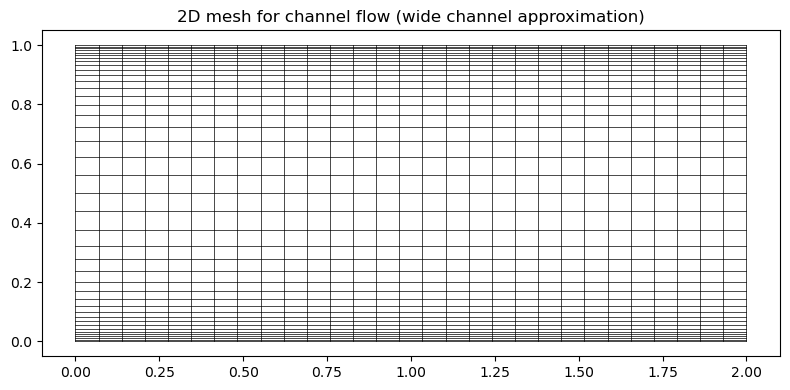

In [5]:
x = np.linspace(0, LW, 30)
y_lower = y_half                              # 0 → H, fine near 0 (bottom wall) ✓ already correct
y_upper = LH - y_half[::-1]                   # H → LH, fine near LH (top wall)
y = np.concatenate([y_lower, y_upper[1:]])    # drop duplicate H at the join

mesh = np.meshgrid(x, y)

plt.figure(figsize=(8, 4))
plt.plot(mesh[0], mesh[1], 'k-', linewidth=0.5)
plt.plot(mesh[0].T, mesh[1].T, 'k-', linewidth=0.5)
plt.title("2D mesh for channel flow (wide channel approximation)")
plt.tight_layout()
plt.show()

In [6]:
print("Mesh shape:", mesh[0].shape, mesh[1].shape)
print("x range:", mesh[0].min(), "to", mesh[0].max())
print("y range:", mesh[1].min(), "to", mesh[1].max())

Mesh shape: (41, 30) (41, 30)
x range: 0.0 to 2.0
y range: 0.0 to 1.0


### mixing length

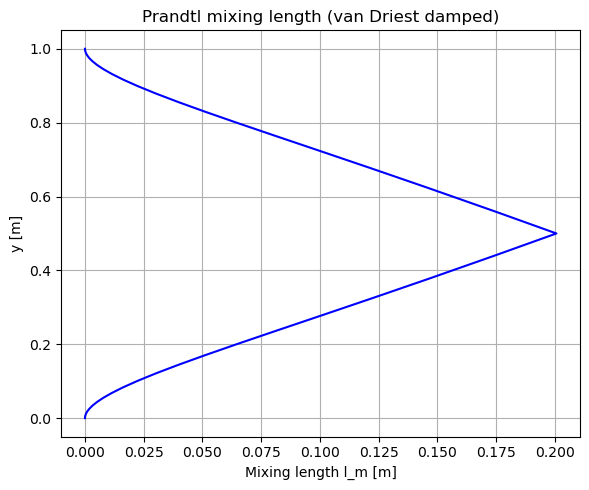

In [7]:
kappa = 0.41    # von Karman constant
A_plus = 26.0   # van Driest damping constant

def mixing_length(y, u_tau, nu, H):
    y_wall = np.minimum(y, 2*H - y)   # distance to nearest wall (2H = LH = full height)
    y_plus = y_wall * u_tau / nu
    lm = kappa * y_wall * (1 - np.exp(-y_plus / A_plus))
    lm = np.minimum(lm, kappa * H)
    return lm


lm = mixing_length(y, u_tau, Nu, H)

plt.figure(figsize=(6, 5))
plt.plot(lm, y, 'b-')
plt.xlabel("Mixing length l_m [m]")
plt.ylabel("y [m]")
plt.title("Prandtl mixing length (van Driest damped)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
# Precompute mixing length at each interior cell FACE (not center) -- these
# only depend on the fixed grid, not on the solution, so they're computed once
# here rather than every time step. Used for the flux-conservative eddy
# diffusion term in momentum_predictor: Gamma_face = Nu + l_m_face^2*|du/dy|.
y_face_n = 0.5 * (y[1:-1] + y[2:])   # midpoint toward the north neighbor
y_face_s = 0.5 * (y[1:-1] + y[:-2])  # midpoint toward the south neighbor

l_m_face_n = mixing_length(y_face_n, u_tau, Nu, H)[:, None]
l_m_face_s = mixing_length(y_face_s, u_tau, Nu, H)[:, None]

# Rough peak eddy viscosity (log-law estimate, nu_t ~ kappa*u_tau*y), used
# only to size a safe time step below -- nu_t can be 20-30x molecular Nu near
# the centerline, so the diffusion stability limit needs the *total*
# viscosity, not just Nu.
nu_t_peak_estimate = kappa * u_tau * H
print("Estimated peak eddy viscosity:", nu_t_peak_estimate, " (vs molecular Nu =", Nu, ")")

Estimated peak eddy viscosity: 0.0006180107312844806  (vs molecular Nu = 1.5e-05 )


### stability setup

In [9]:
Nx = len(x)
Ny = len(y)

print("Number of grid points in x-direction (Nx):", Nx)
print("Number of grid points in y-direction (Ny):", Ny)

dx = x[1] - x[0]  # Uniform grid in x-direction
dy_arr = np.diff(y)      # length Ny-1, dy_arr[i] = y[i+1] - y[i]
dy_s = dy_arr[:-1]        # spacing to the neighbor below, for each interior point (length Ny-2)
dy_n = dy_arr[1:]         # spacing to the neighbor above, for each interior point (length Ny-2)

print("Grid spacing in x-direction (dx):", dx)
print("Grid spacing in y-direction (dy_s):", dy_s)
print("Grid spacing in y-direction (dy_n):", dy_n)

safety_factor = 0.5
dx_min = np.min(dx)
dy_min = np.min(dy_s)  # Using dy_s for consistency

# Diffusion stability must use the *total* viscosity (Nu + eddy viscosity),
# not just molecular Nu -- nu_t can be ~20-30x larger near the centerline.
Nu_eff_for_dt = Nu + nu_t_peak_estimate

dt = safety_factor / (U_bulk / dx_min + U_bulk / dy_min + 2 * Nu_eff_for_dt * (1/dx_min**2 + 1/dy_min**2))
print("Time step (dt):", dt)

CFL_x = U_bulk * dt / dx_min
CFL_y = U_bulk * dt / dy_min

r = Nu_eff_for_dt * dt / dx_min**2

print("CFL number in x-direction:", CFL_x)
print("CFL number in y-direction:", CFL_y)
print("Diffusion number:", r)
print(f"Combined = {CFL_x + CFL_y + 4*r:.4f}  (must be ≤ 1)")

# Reshape to column vectors so they broadcast correctly against the (Ny-2, Nx-2)
# interior arrays used in momentum_predictor / compute_divergence / etc.
dy_s = dy_s[:, None]
dy_n = dy_n[:, None]

nt = 20000  # Number of time steps
T = nt * dt  # Total simulation time
print(f"Total simulation time T = {T:.4f}")

Number of grid points in x-direction (Nx): 30
Number of grid points in y-direction (Ny): 41
Grid spacing in x-direction (dx): 0.06896551724137931
Grid spacing in y-direction (dy_s): [0.00497564 0.00572199 0.00658029 0.00756733 0.00870243 0.01000779
 0.01150896 0.01323531 0.0152206  0.01750369 0.02012925 0.02314863
 0.02662093 0.03061407 0.03520618 0.0404871  0.04656017 0.05354419
 0.06157582 0.06108963 0.06108963 0.06157582 0.05354419 0.04656017
 0.0404871  0.03520618 0.03061407 0.02662093 0.02314863 0.02012925
 0.01750369 0.0152206  0.01323531 0.01150896 0.01000779 0.00870243
 0.00756733 0.00658029 0.00572199]
Grid spacing in y-direction (dy_n): [0.00572199 0.00658029 0.00756733 0.00870243 0.01000779 0.01150896
 0.01323531 0.0152206  0.01750369 0.02012925 0.02314863 0.02662093
 0.03061407 0.03520618 0.0404871  0.04656017 0.05354419 0.06157582
 0.06108963 0.06108963 0.06157582 0.05354419 0.04656017 0.0404871
 0.03520618 0.03061407 0.02662093 0.02314863 0.02012925 0.01750369
 0.0152206 

### Initial Condition

In [10]:
u = np.full_like(mesh[0], U_bulk)  # Initial guess: uniform bulk velocity
v = np.zeros_like(mesh[1])         # Initial guess: zero vertical velocity
p = np.zeros_like(mesh[0])         # Initial guess: zero pressure field
print("Initial velocity field shape:", u.shape)

Initial velocity field shape: (41, 30)


### Body Force (periodic channel forcing)

In [11]:
# Periodic channel has no inlet/outlet pressure drop to drive the flow, so we
# replace it with a constant streamwise body force (= mean pressure gradient).
# From the exact plane-Poiseuille solution: dp/dx = -12*mu*U_bulk/LH^2
# Force per unit mass added to the u-momentum equation: f_x = -(1/rho)*dp/dx = 12*Nu*U_bulk/LH^2
f_x = 12 * Nu * U_bulk / LH**2
print("Body force f_x:", f_x)

Body force f_x: 8.1e-06


## Algorithm Per Time Step

### Apply BC

In [12]:
def apply_boundary_conditions(u, v):
    # Periodic in x: column 0 wraps to the second-to-last column, and the last
    # column wraps to the second column, so interior stencils at the domain
    # edges see the correct periodic neighbor.
    u[:, 0] = u[:, -2]
    v[:, 0] = v[:, -2]
    u[:, -1] = u[:, 1]
    v[:, -1] = v[:, 1]

    # Top and bottom boundary conditions (No-slip)
    u[0, :] = 0.0 # No-slip: zero velocity in y-direction
    v[0, :] = 0.0 # No-slip: zero velocity in y-direction
    u[-1, :] = 0.0 # No-slip: zero velocity in y-direction
    v[-1, :] = 0.0 # No-slip: zero velocity in y-direction

    return u, v

## Momentum Predictor - Compute u*, v* (momentum without pressure)

In [13]:
def momentum_predictor(u, v, dx, dy_s, dy_n, dt, Nu, l_m_face_n, l_m_face_s, f_x=0.0):
    un = u.copy()
    vn = v.copy()

    u_star = un.copy()
    v_star = vn.copy()

    # Neighbours of u, v - interior points only
    u_e = un[1:-1, 2:]   # u[i, j+1]
    u_w = un[1:-1, :-2]  # u[i, j-1]
    u_n = un[2:, 1:-1]   # u[i+1, j]
    u_s = un[:-2, 1:-1]  # u[i-1, j]
    u_c = un[1:-1, 1:-1]

    v_e = vn[1:-1, 2:]   # v[i, j+1]
    v_w = vn[1:-1, :-2]  # v[i, j-1]
    v_n = vn[2:, 1:-1]   # v[i+1, j]
    v_s = vn[:-2, 1:-1]  # v[i-1, j]
    v_c = vn[1:-1, 1:-1]

    # Convection terms - Upwind scheme
    conv_u_x = np.maximum(u_c, 0) * (u_c - u_w)/dx + np.minimum(u_c, 0) * (u_e - u_c)/dx
    conv_u_y = np.maximum(v_c, 0) * (u_c - u_s)/dy_s + np.minimum(v_c, 0) * (u_n - u_c)/dy_n

    conv_v_x = np.maximum(u_c, 0) * (v_c - v_w)/dx + np.minimum(u_c, 0) * (v_e - v_c)/dx
    conv_v_y = np.maximum(v_c, 0) * (v_c - v_s)/dy_s + np.minimum(v_c, 0) * (v_n - v_c)/dy_n

    conv_u = conv_u_x + conv_u_y
    conv_v = conv_v_x + conv_v_y

    # Eddy viscosity (Boussinesq / mixing-length closure): a single turbulent
    # viscosity built from the mean shear |du/dy|, evaluated at each cell
    # face, added to molecular Nu and applied uniformly to every diffusion
    # term (isotropic eddy-viscosity hypothesis) -- this is what makes the
    # solve "RANS with a mixing-length model" rather than plain laminar.
    dudy_n = (u_n - u_c) / dy_n   # shear at the north face
    dudy_s = (u_c - u_s) / dy_s   # shear at the south face
    Gamma_n = Nu + l_m_face_n**2 * np.abs(dudy_n)
    Gamma_s = Nu + l_m_face_s**2 * np.abs(dudy_s)

    # Flux-conservative y-diffusion for the variable total viscosity Gamma(y):
    #   d/dy(Gamma du/dy) ~= [Gamma_n*(u_n-u_c)/dy_n - Gamma_s*(u_c-u_s)/dy_s] / (0.5*(dy_s+dy_n))
    diff_u_y = (Gamma_n * dudy_n - Gamma_s * dudy_s) * 2 / (dy_s + dy_n)

    dvdy_n = (v_n - v_c) / dy_n
    dvdy_s = (v_c - v_s) / dy_s
    diff_v_y = (Gamma_n * dvdy_n - Gamma_s * dvdy_s) * 2 / (dy_s + dy_n)

    # x-diffusion uses molecular viscosity only: the mean flow has no
    # streamwise gradient once fully developed, so this term vanishes at
    # convergence regardless.
    diff_u_x = Nu * (u_e - 2*u_c + u_w) / dx**2
    diff_v_x = Nu * (v_e - 2*v_c + v_w) / dx**2

    diff_u = diff_u_x + diff_u_y
    diff_v = diff_v_x + diff_v_y

    u_star[1:-1, 1:-1] = u_c + dt * (diff_u - conv_u + f_x)
    v_star[1:-1, 1:-1] = v_c + dt * (diff_v - conv_v)

    return u_star, v_star

## Compute divergence b = ∇·u*

In [14]:
# compute the divergence of the intermediate velocity field
def compute_divergence(u_star, v_star, dx, dy_s, dy_n):
    du_dx = (u_star[1:-1, 2:] - u_star[1:-1, :-2]) / (2*dx)

    # Non-uniform central difference for dv/dy:
    #   f'_i ~= [dy_s^2*(f_n - f_i) + dy_n^2*(f_i - f_s)] / (dy_s*dy_n*(dy_s+dy_n))
    # (reduces to the standard (f_n - f_s)/(2*dy) when dy_s == dy_n)
    v_c = v_star[1:-1, 1:-1]
    v_n = v_star[2:, 1:-1]
    v_s = v_star[:-2, 1:-1]
    dv_dy = (dy_s**2 * (v_n - v_c) + dy_n**2 * (v_c - v_s)) / (dy_s * dy_n * (dy_s + dy_n))

    div = du_dx + dv_dy
    return div

## Connector - Pressure Poisson Solver

In [15]:
def pressure_poisson_connector(u_star, v_star, p, dx, dy_s, dy_n, dt, rho=1.0, max_iter=500, tol=1e-4):
    # Non-uniform 5-point Laplacian weights (y is wall-stretched, x is uniform).
    # d2p/dy2 ~= Ay_n*p_n + Ay_s*p_s - Ay_center*p   (Ay_center = Ay_n + Ay_s)
    Ax = 1.0 / dx**2
    Ay_n = 2.0 / (dy_n * (dy_s + dy_n))
    Ay_s = 2.0 / (dy_s * (dy_s + dy_n))
    Ay_center = Ay_n + Ay_s

    # Solve the Poisson equation iteratively
    for it in range(max_iter):
        p_old = p.copy()

        # Neighbours of p - interior points only
        p_e = p_old[1:-1, 2:]   # p[i, j+1]
        p_w = p_old[1:-1, :-2]  # p[i, j-1]
        p_n = p_old[2:, 1:-1]   # p[i+1, j]
        p_s = p_old[:-2, 1:-1]  # p[i-1, j]

        div = compute_divergence(u_star, v_star, dx, dy_s, dy_n)

        rhs = (rho / dt) * div

        # Jacobi update for pressure
        p[1:-1, 1:-1] = (Ax * (p_e + p_w) + Ay_n * p_n + Ay_s * p_s - rhs) / (2 * Ax + Ay_center)

        # Boundary conditions for pressure: Neumann (dp/dn=0) at the walls,
        # periodic in x (matching the velocity BCs).
        p[0, :] = p[1, :]     # dp/dy=0 at bottom
        p[-1, :] = p[-2, :]   # dp/dy=0 at top
        p[:, 0] = p[:, -2]
        p[:, -1] = p[:, 1]

        # Periodic-x + all-Neumann-y BCs leave the pressure defined only up to
        # an additive constant (no Dirichlet reference anywhere) -> pin it by
        # removing the mean every iteration.
        p -= p.mean()

        # Check for convergence
        if np.linalg.norm(p - p_old) < tol:
            break
    else:
        print("Pressure Poisson did not converge within the maximum iterations.")
    
    return p

## Correct: u = u* - dt·∂p/∂x,  v = v* - dt·∂p/∂y

In [16]:
def velocity_corrector(u_star, v_star, p, dx, dy_s, dy_n, dt, rho=1.0):
    u = u_star.copy()
    v = v_star.copy()

    # Neighbours of p - interior points only
    p_e = p[1:-1, 2:]   # p[i, j+1]
    p_w = p[1:-1, :-2]  # p[i, j-1]
    p_c = p[1:-1, 1:-1] # p[i, j]
    p_n = p[2:, 1:-1]   # p[i+1, j]
    p_s = p[:-2, 1:-1]  # p[i-1, j]

    # Non-uniform central difference for dp/dy (same weighting as compute_divergence)
    dp_dy = (dy_s**2 * (p_n - p_c) + dy_n**2 * (p_c - p_s)) / (dy_s * dy_n * (dy_s + dy_n))

    u[1:-1, 1:-1] = u_star[1:-1, 1:-1] - (dt/rho) * (p_e - p_w) / (2*dx)
    v[1:-1, 1:-1] = v_star[1:-1, 1:-1] - (dt/rho) * dp_dy

    return u, v

## Track ${max|u^{n+1} - u^n|}$ for steady state convergence

In [17]:
def check_convergence(u, v, u_old, v_old, tol=1e-4):
    du = np.linalg.norm(u - u_old)
    dv = np.linalg.norm(v - v_old)
    return du < tol and dv < tol

## main loop

In [18]:
residual_history = []
u_history = []
v_history = []
p_history = []
f_x_history = []

f_x_relax = 0.2  # under-relaxation for the body-force correction (see below)

for n in range(nt):
    u_old = u.copy()
    v_old = v.copy()
    p_old = p.copy()

    u_old, v_old = apply_boundary_conditions(u_old, v_old)
    u_star, v_star = momentum_predictor(u_old, v_old, dx, dy_s, dy_n, dt, Nu, l_m_face_n, l_m_face_s, f_x=f_x)
    p = pressure_poisson_connector(u_star, v_star, p_old, dx, dy_s, dy_n, dt, rho=rho)
    u, v = velocity_corrector(u_star, v_star, p, dx, dy_s, dy_n, dt, rho=rho)

    u, v = apply_boundary_conditions(u, v)

    # Dynamic body-force correction: nudge f_x so the bulk velocity tracks the
    # target U_bulk. The analytical f_x from the Body Force cell only holds
    # exactly for the *laminar* profile -- eddy viscosity changes the drag,
    # so without this correction the converged U_bulk would drift off target.
    # Under-relaxed (f_x_relax < 1): applying the FULL instantaneous deficit
    # correction every step overshoots (the flow doesn't respond instantly)
    # and rings in a persistent limit cycle instead of settling.
    # (Manual trapezoidal rule -- np.trapz was removed in NumPy 2.0.)
    profile = u.mean(axis=1)
    U_bulk_now = np.sum((profile[1:] + profile[:-1]) / 2 * np.diff(y)) / LH
    f_x += f_x_relax * (U_bulk - U_bulk_now) / dt

    if n % 50 == 0:
        u_history.append(u.copy())
        v_history.append(v.copy())
        p_history.append(p.copy())
        f_x_history.append(f_x)

    residual = np.max(np.abs(u - u_old))
    residual_history.append(residual)
    if n % 100 == 0:
        print(f"Step {n:4d} | residual = {residual:.2e} | f_x = {f_x:.3e} | U_bulk_now = {U_bulk_now:.5f}")

    if check_convergence(u, v, u_old, v_old, tol=1e-8):
        print(f"Converged to steady state at step {n}")
        break

Step    0 | residual = 2.08e-04 | f_x = 5.533e-03 | U_bulk_now = 0.04477
Step  100 | residual = 9.71e-05 | f_x = 1.170e-02 | U_bulk_now = 0.04495
Step  200 | residual = 7.42e-05 | f_x = 4.815e-03 | U_bulk_now = 0.04515
Step  300 | residual = 5.08e-05 | f_x = -5.821e-03 | U_bulk_now = 0.04516
Step  400 | residual = 9.76e-05 | f_x = -8.471e-03 | U_bulk_now = 0.04500
Step  500 | residual = 6.26e-05 | f_x = -1.616e-03 | U_bulk_now = 0.04487
Step  600 | residual = 3.64e-05 | f_x = 6.066e-03 | U_bulk_now = 0.04489
Step  700 | residual = 6.41e-05 | f_x = 6.236e-03 | U_bulk_now = 0.04503
Step  800 | residual = 2.45e-05 | f_x = -2.225e-04 | U_bulk_now = 0.04512
Step  900 | residual = 4.48e-05 | f_x = -5.542e-03 | U_bulk_now = 0.04506
Step 1000 | residual = 5.53e-05 | f_x = -4.160e-03 | U_bulk_now = 0.04495
Step 1100 | residual = 1.61e-05 | f_x = 1.663e-03 | U_bulk_now = 0.04490
Step 1200 | residual = 4.07e-05 | f_x = 5.130e-03 | U_bulk_now = 0.04497
Step 1300 | residual = 3.78e-05 | f_x = 2.748

### Post-processing / Visualization

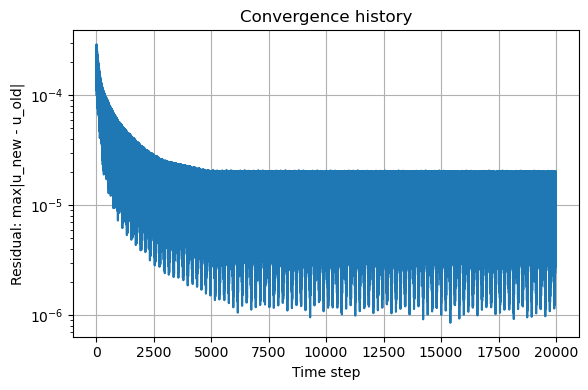

In [19]:
plt.figure(figsize=(6, 4))
plt.semilogy(residual_history)
plt.xlabel("Time step")
plt.ylabel("Residual: max|u_new - u_old|")
plt.title("Convergence history")
plt.grid(True)
plt.tight_layout()
plt.show()

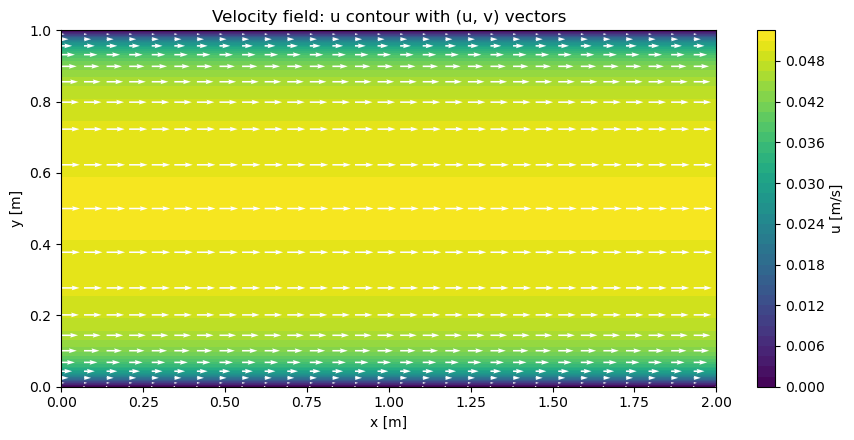

In [20]:
skip_x = max(1, Nx // 20)
skip_y = max(1, Ny // 20)

plt.figure(figsize=(9, 4.5))
cf = plt.contourf(mesh[0], mesh[1], u, levels=50, cmap='viridis')
plt.colorbar(cf, label="u [m/s]")
plt.quiver(mesh[0][::skip_y, ::skip_x], mesh[1][::skip_y, ::skip_x],
           u[::skip_y, ::skip_x], v[::skip_y, ::skip_x],
           color='white', scale=U_bulk*40)
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Velocity field: u contour with (u, v) vectors")
plt.tight_layout()
plt.show()

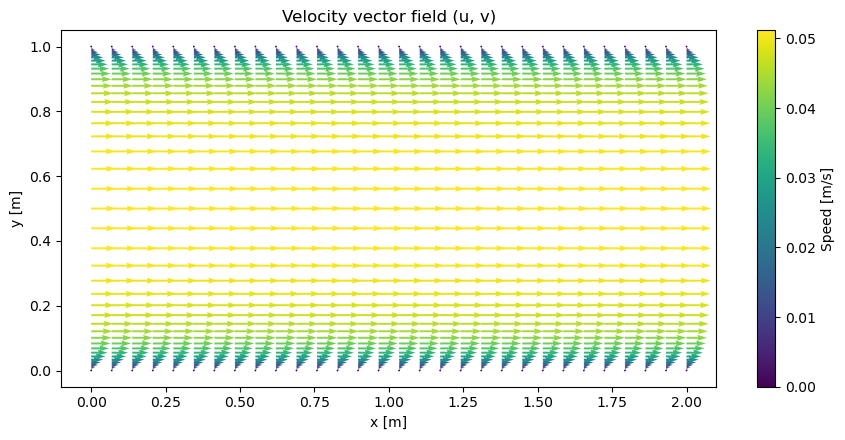

In [21]:
skip_x = max(1, Nx // 25)
skip_y = max(1, Ny // 25)
speed = np.sqrt(u**2 + v**2)

plt.figure(figsize=(9, 4.5))
q = plt.quiver(mesh[0][::skip_y, ::skip_x], mesh[1][::skip_y, ::skip_x],
               u[::skip_y, ::skip_x], v[::skip_y, ::skip_x],
               speed[::skip_y, ::skip_x], cmap='viridis',
               scale=U_bulk * 30, width=0.003)
plt.colorbar(q, label="Speed [m/s]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Velocity vector field (u, v)")
plt.tight_layout()
plt.show()

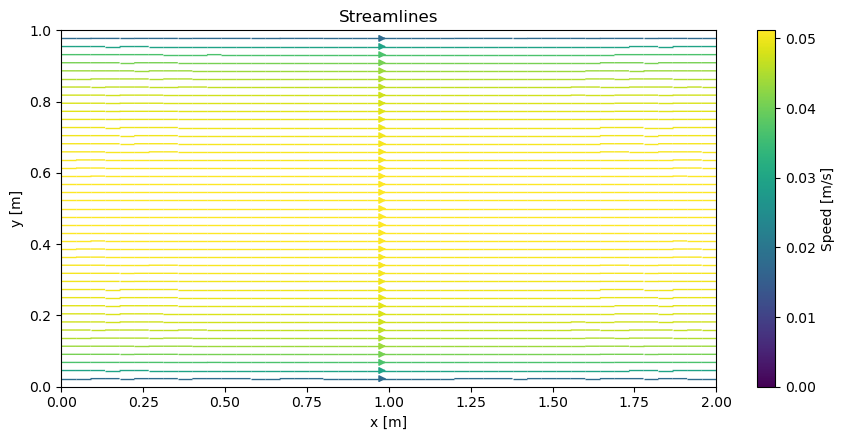

In [22]:
# streamplot requires an evenly spaced grid; interpolate u, v from the
# wall-stretched y onto a uniform y just for this plot (solver data untouched).
y_uniform = np.linspace(0, LH, Ny)
u_uniform = np.array([np.interp(y_uniform, y, u[:, j]) for j in range(Nx)]).T
v_uniform = np.array([np.interp(y_uniform, y, v[:, j]) for j in range(Nx)]).T
speed_uniform = np.sqrt(u_uniform**2 + v_uniform**2)

plt.figure(figsize=(9, 4.5))
strm = plt.streamplot(x, y_uniform, u_uniform, v_uniform, density=1.5, color=speed_uniform, cmap='viridis', linewidth=1)
plt.colorbar(strm.lines, label="Speed [m/s]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Streamlines")
plt.tight_layout()
plt.show()

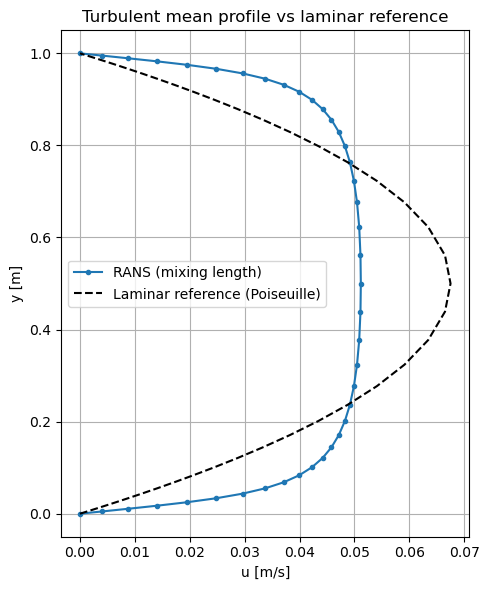

In [23]:
# Reference: exact laminar (plane Poiseuille) profile -- NOT what we expect to
# match now. With eddy viscosity active, the converged profile should be
# flatter/more plug-like in the core (turbulent mixing transports momentum
# more efficiently) with a steeper gradient right at the wall, versus the
# smooth parabola of the pure-laminar case.
u_laminar_ref = 6 * U_bulk * (y / LH) * (1 - y / LH)
u_mean_profile = u.mean(axis=1)

plt.figure(figsize=(5, 6))
plt.plot(u_mean_profile, y, 'o-', markersize=3, label="RANS (mixing length)")
plt.plot(u_laminar_ref, y, 'k--', label="Laminar reference (Poiseuille)")
plt.xlabel("u [m/s]")
plt.ylabel("y [m]")
plt.title("Turbulent mean profile vs laminar reference")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

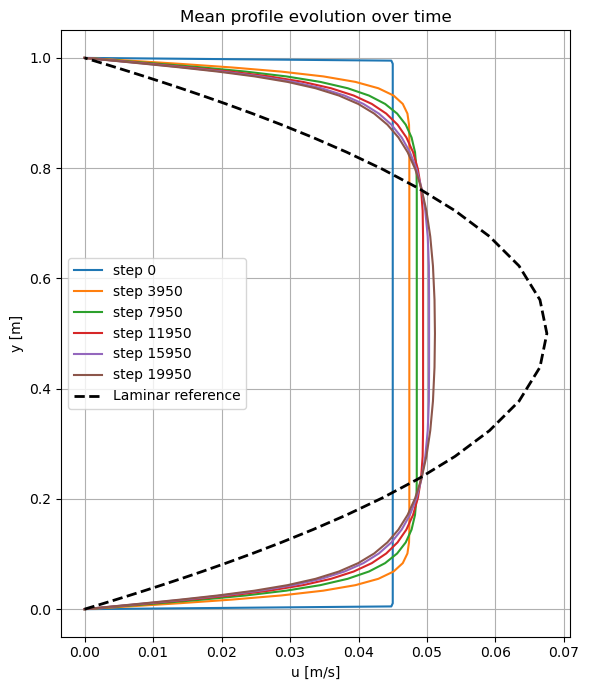

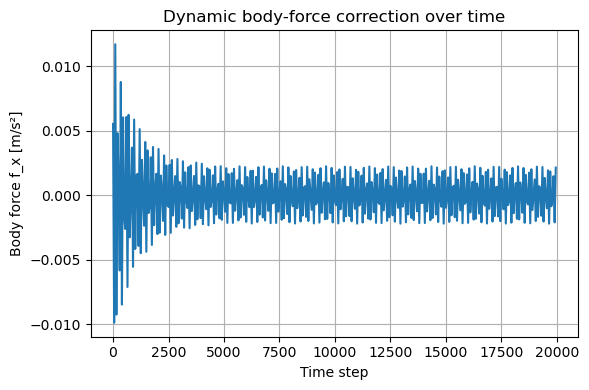

Achieved u_tau: 0.003519731967932821  (initial estimate was: 0.003014686494070637 )


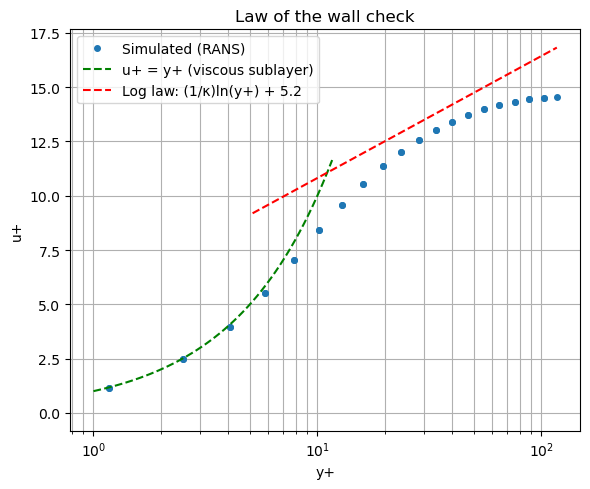

In [24]:
# Mean profile evolution over time: watch it relax from the laminar-parabola
# initial guess toward the flatter turbulent profile.
plt.figure(figsize=(6, 7))
snapshot_indices = np.linspace(0, len(u_history) - 1, 6, dtype=int)
for idx in snapshot_indices:
    step_n = idx * 50
    mean_profile = u_history[idx].mean(axis=1)
    plt.plot(mean_profile, y, label=f"step {step_n}")
plt.plot(u_laminar_ref, y, 'k--', linewidth=2, label="Laminar reference")
plt.xlabel("u [m/s]")
plt.ylabel("y [m]")
plt.title("Mean profile evolution over time")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Dynamic body-force correction: should settle to a steady value once the
# mean flow (and hence the wall drag it has to balance) stops changing.
plt.figure(figsize=(6, 4))
plt.plot(np.arange(len(f_x_history)) * 50, f_x_history)
plt.xlabel("Time step")
plt.ylabel("Body force f_x [m/s²]")
plt.title("Dynamic body-force correction over time")
plt.grid(True)
plt.tight_layout()
plt.show()

# Law-of-the-wall check -- the key validation for a mixing-length RANS model.
# Recompute u_tau from the *achieved* wall shear stress (the initial estimate
# in "Compute y+" used a laminar-flow friction correlation, which no longer
# applies exactly once eddy viscosity is active and f_x has been corrected).
dudy_wall = (u[1, :] - u[0, :]) / (y[1] - y[0])
tau_w_achieved = rho * Nu * np.mean(np.abs(dudy_wall))
u_tau_achieved = np.sqrt(tau_w_achieved / rho)
print("Achieved u_tau:", u_tau_achieved, " (initial estimate was:", u_tau, ")")

y_plus = np.minimum(y, LH - y) * u_tau_achieved / Nu
u_plus = u_mean_profile / u_tau_achieved

y_plus_log = np.logspace(0, np.log10(y_plus.max()), 100)
u_plus_viscous = y_plus_log            # u+ = y+ in the viscous sublayer
u_plus_log_law = (1/kappa) * np.log(y_plus_log) + 5.2

plt.figure(figsize=(6, 5))
plt.semilogx(y_plus, u_plus, 'o', markersize=4, label="Simulated (RANS)")
mask_visc = y_plus_log < 12
mask_log = y_plus_log > 5
plt.semilogx(y_plus_log[mask_visc], u_plus_viscous[mask_visc], 'g--', label="u+ = y+ (viscous sublayer)")
plt.semilogx(y_plus_log[mask_log], u_plus_log_law[mask_log], 'r--', label="Log law: (1/κ)ln(y+) + 5.2")
plt.xlabel("y+")
plt.ylabel("u+")
plt.title("Law of the wall check")
plt.legend()
plt.grid(True, which='both')
plt.tight_layout()
plt.show()

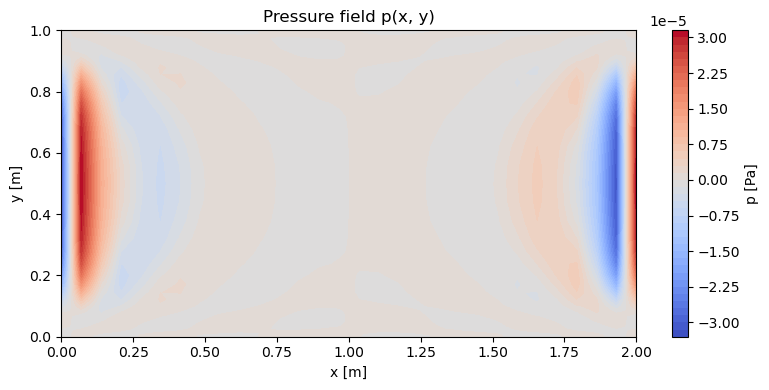

In [25]:
plt.figure(figsize=(8, 4))
cf = plt.contourf(mesh[0], mesh[1], p, levels=50, cmap='coolwarm')
plt.colorbar(cf, label="p [Pa]")
plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("Pressure field p(x, y)")
plt.tight_layout()
plt.show()